# Plotting & Evaluation

In [1]:
# Standard library imports
import os
import sys
import io

# Data handling and scientific computing
import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy.linalg import inv

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split
from torch_geometric.nn import GCNConv, NNConv
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

# RDKit for cheminformatics
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, GetPeriodicTable
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdchem
from rdkit.Chem import rdmolops
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import rdMolHash


# NetworkX for network analysis
import networkx as nx

# Matplotlib for plotting and visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# Other utilities
from tqdm import tqdm
from PIL import Image

# External datasets
from datasets import load_dataset


import re
import random


from IPython.display import display

sys.path.append('./Code/TestingGround/src/models/')

/home/knkn308/.conda/envs/env-protac-toolkit/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from all_functions import *

In [3]:
# user input

modes = ['plot', 'dont plot']
mode = modes[1]   #['plot', 'dont plot']      
num_plotted_protacs = 50 #    

load_testsets = True
dataname = "NoGraphDesc_2K"  #Existing_datanames[0] # Which dataset to use
model_name = "GraphConv_B_size2_rand20Ktrain"

## Plotting functions

['blue', 'red', 'red', 'blue', 'red', 'red', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'blue', 'red', 'red', 'red', 'blue', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'red', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'blue', 'blue', 'blue', 'blue']


(-28.570016507068885,
 23.567267047466146,
 -13.122730450483422,
 8.075054945759351)

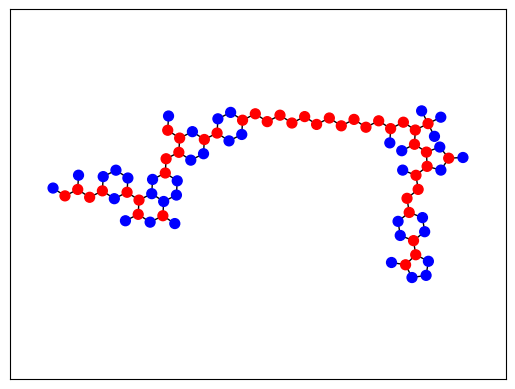

In [4]:
smi = 'C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1'
G, pos = make_graph_with_pos(smi)

bool_list, highlighted_nodes = identify_bridge_nodes(G)

colors = []
for node_idx in range(G.number_of_nodes()):
    if node_idx in highlighted_nodes:
        colors.append('red')
    else:
        colors.append('blue')

#colors = ['red' if node_idx in highlighted_nodes else 'blue' for node_idx in range(G.number_of_nodes())]
print(colors)
nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')

(-28.570016507068885,
 23.567267047466146,
 -13.122730450483422,
 8.075054945759351)

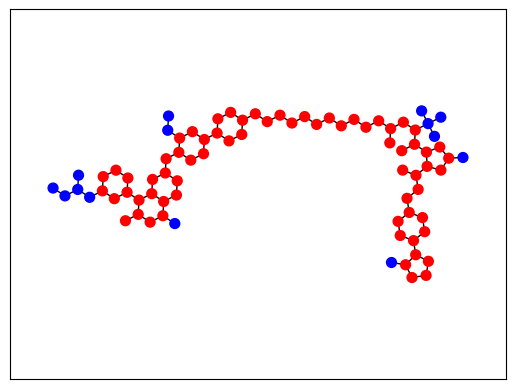

In [5]:
from rdkit.Chem.Scaffolds import MurckoScaffold
smi = 'C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1'
mol = Chem.MolFromSmiles(smi)


ms_bool_list, at_idx_list = identify_murcko_scaffold_atoms(mol)

G, pos = make_graph_with_pos(smi)

colors = []
for node_idx in range(G.number_of_nodes()):
    if node_idx in at_idx_list:
        colors.append('red')
    else:
        colors.append('blue')

nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')


['blue', 'blue', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'blue', 'red', 'red', 'red', 'blue', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'red', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'blue']


(-28.570016507068885,
 23.567267047466146,
 -13.122730450483422,
 8.075054945759351)

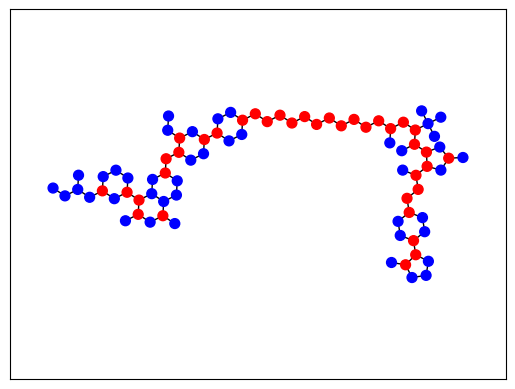

In [6]:
smi = 'C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1'
G, pos = make_graph_with_pos(smi)

bridge_bool_list, highlighted_nodes = identify_bridge_nodes(G)
ms_bool_list, at_idx_list = identify_murcko_scaffold_atoms(mol)


colors = []
for b1, b2 in zip(bridge_bool_list, ms_bool_list):
    if b1*b2:
        colors.append('red')
    else:
        colors.append('blue')

#colors = ['red' if node_idx in highlighted_nodes else 'blue' for node_idx in range(G.number_of_nodes())]
print(colors)
nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')


[5, 9, 10, 11, 14, 19, 20, 21, 24, 25, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 42, 43, 44, 46, 48, 51, 52, 54, 55, 56, 59, 60, 64, 75]


(-28.570016507068885,
 23.567267047466146,
 -13.122730450483422,
 8.075054945759351)

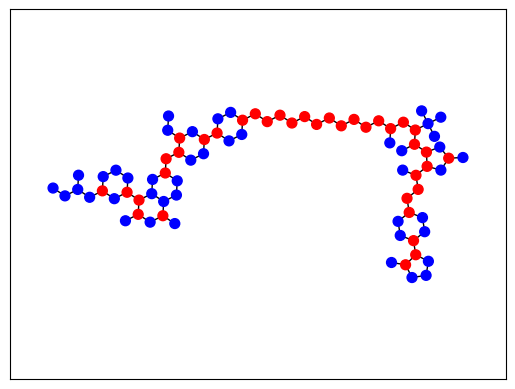

In [7]:
smi = 'C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1'
mol = Chem.MolFromSmiles(smi)
#G, pos = make_graph_with_pos(smi)

#bridge_bool_list, highlighted_nodes = identify_bridge_nodes_and_reject_small_splits(G, smallest_allowed_subgraph_size=9)
#ms_bool_list, at_idx_list = identify_murcko_scaffold_atoms(mol)

bool_combined_list, at_idx_combined_list = identify_legal_nodes(mol, smallest_allowed_subgraph_size=10)


colors = []
for b in bool_combined_list:
    if b:
        colors.append('red')
    else:
        colors.append('blue')

print(at_idx_combined_list)

nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')

## Load data and model

In [8]:
test_set_names_core = ['test_set_1_non_public_poi_v1', 'test_set_2_non_public_e3_v1', 'test_set_3__non_public_linker_v1', 'test_set_4_non_public_protac', 'test_set_5_public_protac_v1', 'test_set_1_2_non_public_poi_and_linker', 'test_set_2_2_non_public_e3_and_linker']
test_set_names = [s + dataname for s in test_set_names_core]

current_directory = os.getcwd()
raw_data_path = os.path.join(current_directory, "..", "..", "data","processed")

In [9]:
training_dataset = load_PROTACdataset(name=f'{dataname}_train_rand', raw_data_path=raw_data_path)
validation_dataset = load_PROTACdataset(name=f'{dataname}_val_rand', raw_data_path=raw_data_path)

if load_testsets:
    if isinstance(load_testsets,list):
        for i in load_testsets:
            if i == 0:
                test_dataset_1 = load_PROTACdataset(name=test_set_names[0], raw_data_path=raw_data_path)
            if i == 1:
                test_dataset_2 = load_PROTACdataset(name=test_set_names[1], raw_data_path=raw_data_path)
            if i == 2:
                test_dataset_3 = load_PROTACdataset(name=test_set_names[2], raw_data_path=raw_data_path)
            if i == 3:
                test_dataset_4 = load_PROTACdataset(name=test_set_names[3], raw_data_path=raw_data_path)
            if i == 4:
                test_dataset_5 = load_PROTACdataset(name=test_set_names[4], raw_data_path=raw_data_path)
            if i == 5:
                test_dataset_1_2 = load_PROTACdataset(name=test_set_names[5], raw_data_path=raw_data_path)
            if i == 6:
                test_dataset_2_2 = load_PROTACdataset(name=test_set_names[6], raw_data_path=raw_data_path)
    else:
        test_dataset_1 = load_PROTACdataset(name=test_set_names[0], raw_data_path=raw_data_path)
        test_dataset_2 = load_PROTACdataset(name=test_set_names[1], raw_data_path=raw_data_path)
        test_dataset_3 = load_PROTACdataset(name=test_set_names[2], raw_data_path=raw_data_path)
        test_dataset_4 = load_PROTACdataset(name=test_set_names[3], raw_data_path=raw_data_path)
        test_dataset_5 = load_PROTACdataset(name=test_set_names[4], raw_data_path=raw_data_path)
        test_dataset_1_2 = load_PROTACdataset(name=test_set_names[5], raw_data_path=raw_data_path)
        test_dataset_2_2 = load_PROTACdataset(name=test_set_names[6], raw_data_path=raw_data_path)

Processing...
0it [00:00, ?it/s]
Done!
Processing...
0it [00:00, ?it/s]
Done!
Processing...
0it [00:00, ?it/s]
Done!
Processing...
0it [00:00, ?it/s]
Done!
Processing...
0it [00:00, ?it/s]
Done!
Processing...
0it [00:00, ?it/s]
Done!
Processing...
0it [00:00, ?it/s]
Done!


In [10]:
model = torch.load(model_name)
model.eval()

NodeClassifierGNN(
  (conv1): GraphConv(11, 64)
  (conv2): GraphConv(64, 64)
  (conv3): GraphConv(64, 64)
  (conv4): GraphConv(64, 64)
  (conv5): GraphConv(64, 64)
  (conv6): GraphConv(64, 64)
  (out): Linear(in_features=64, out_features=3, bias=True)
)

## Plots & metrics

In [11]:
scale_factor_nodes=1.8 
chosen_dataset = validation_dataset #val_dataset
#mode = modes[0]
if mode == modes[0]:
    prediction_range = range(num_plotted_protacs)        
else: 
    prediction_range = range(len(chosen_dataset))


In [12]:
num_mislabelled = {}
num_mislabelled_POI = {}
num_mislabelled_Linker = {}
num_mislabelled_E3 = {}
POI_MCS_maxatoms_list = []
Linker_MCS_maxatoms_list = []
E3_MCS_maxatoms_list = []
Confusion3Matrix_sum = [[0, 0, 0], [0, 0, 0], [0, 0, 0]]

for idx in prediction_range:# prediction_range:
    #Prediction
    molecule_data, G_pred, protac_smile, substructure_smiles, poi_smile, linker_smile, e3_smile = unpack_datapoint(chosen_dataset, idx)
    class_predictions, probabilities = predict(model, molecule_data)

    

    #check
    POI_boundary_node, E3_boundary_node= get_predicted_boundary_nodes(model, molecule_data)
    
    model.eval()
    with torch.no_grad():
        out = model(molecule_data.x, molecule_data.edge_index)
    intermediate_path_nodes, path_nodes, POI_nodes, linker_nodes,  E3_nodes = process_boundaries_to_substructures(molecule_data, out, return_intermediate_path_nodes=True)
    #vizualize_protac_From_Graph(G_pred, node_size=80)
    #vizualize_protac_From_Graph(G_pred, node_size=80, highlighted_nodes=[POI_boundary_node])
    #print(f'intermediate_path_nodes.tolist(): {intermediate_path_nodes}')
    #vizualize_protac_From_Graph(G_pred, node_size=80, highlighted_nodes=path_nodes)
    check_permutation_invariance(molecule_data, model, class_predictions, probabilities) #Raises an error if not permutation invariant
    
    #printing
    class_predictions_list = class_predictions.tolist()
    color_mapping = {0: 'red', 1: 'gray', 2: 'blue'}     # Define color mapping
    colours_pred = [color_mapping[class_pred] for class_pred in class_predictions_list]     # Map each class prediction to its corresponding color

    # Create a figure and axes for the predicted graph
    G_pred, pos = assign_pos_to_graph(smile=protac_smile, G=G_pred)
    fig_pred, ax_pred = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_pred, pos, node_color=colours_pred, with_labels=False, node_size=100, ax=ax_pred)
    ax_pred.set_title("Predicted")
    ax_pred.axis('equal')
    ax_pred.axis('off')  # Optional: to turn off the axis
    plt.close(fig_pred)  # Close the figure to prevent it from being displayed

    # Create a figure and axes for the ground truth graph
    G_gt, colors_groundtruth = make_groundtruth_graph(protac_smile, substructure_smiles)
    
    fig_gt, ax_gt = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_gt, pos, node_color=colors_groundtruth, with_labels=False, node_size=100, ax=ax_gt)
    ax_gt.set_title("Ground Truth")
    ax_gt.axis('equal')
    ax_gt.axis('off')  # Optional: to turn off the axis
    plt.close(fig_gt)  # Close the figure to prevent it from being displayed

    if mode == modes[0]:
        print('index: ', idx)
        print('protac_smile', protac_smile)
        # Combine and display the two figures
        combine_two_figures(fig_gt, fig_pred)

    

    # ------------------- Calculations for evaluation metrics below -------------------

    
    substruct_smiles=chosen_dataset[idx].substructure_smiles
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substruct_smiles)
    one_hot_direct = one_hot_encode_substructure_labels(protac_smile, poi_smile, e3_smile)
    node_feature_dim = training_dataset.num_node_features 
    edge_feature_dim = training_dataset.num_edge_features



    # Num nodes mislabelled nodes for whole PROTAC. For bar plot
    total_num_nodes = len(chosen_dataset[idx].node_substructure_label.argmax(dim=1))
    correctly_labled_nodes = class_predictions.eq(chosen_dataset[idx].node_substructure_label.argmax(dim=1)).sum().item()
    num_mislabelled_nodes = total_num_nodes - correctly_labled_nodes
    if num_mislabelled_nodes in num_mislabelled:
        num_mislabelled[num_mislabelled_nodes] += 1
    else:
        num_mislabelled[num_mislabelled_nodes] = 1

    
    # Get maximum common substructure (correctly labeled nodes / (union of predicted nodes and true nodes))
    true_class_labels = chosen_dataset[idx].node_substructure_label.argmax(dim=1)
    #print(f'true_class_labels: {true_class_labels}')
    #print(f'class_predictions: {class_predictions}')
    MCS_maxatoms_substructures = MaxCommonSubstructure_maxatoms(true_class_labels, class_predictions)
    for class_label in [0, 1, 2]:
        if class_label == 0:
            POI_MCS_maxatoms_list.append(MCS_maxatoms_substructures[0].numpy())
        elif class_label == 1:
            Linker_MCS_maxatoms_list.append(MCS_maxatoms_substructures[1].numpy())
        elif class_label == 2:
            E3_MCS_maxatoms_list.append(MCS_maxatoms_substructures[2].numpy())
        else:
            raise ValueError(f'MaxCommonSubstructure_maxatoms() gives a bad output')


    #Get num mislabeled for individual substructures
    incorrect_predicted_labels_substructure_list = mislabelled_nodes_in_substructures(true_class_labels, class_predictions)
    num_mislabelled_list = [num_mislabelled_POI, num_mislabelled_Linker, num_mislabelled_E3]
    num_mislabelled_nodes_list = [0, 0, 0]
    for class_label in [0, 1, 2]:
        num_mislabelled_nodes_substructure = incorrect_predicted_labels_substructure_list[class_label].item()     
        num_mislabelled_nodes_list[class_label] += num_mislabelled_nodes_substructure
        if num_mislabelled_nodes_substructure in num_mislabelled_list[class_label]:
            num_mislabelled_list[class_label][num_mislabelled_nodes_substructure] += 1
        else:
            num_mislabelled_list[class_label][num_mislabelled_nodes_substructure] = 1

        #if class_label == 0:
        #    num_mislabelled_nodes_POI = incorrect_predicted_labels_substructure_list[0].item()
        #    if num_mislabelled_nodes_POI in num_mislabelled_POI:
        #        num_mislabelled_POI[num_mislabelled_nodes_POI] += 1
        #    else:
        #        num_mislabelled_POI[num_mislabelled_nodes_POI] = 1
        #elif class_label == 1:
        #    num_mislabelled_nodes_Linker = incorrect_predicted_labels_substructure_list[1].item()
        #    if num_mislabelled_nodes_Linker in num_mislabelled_Linker:
        #        num_mislabelled_Linker[num_mislabelled_nodes_Linker] += 1
        #    else:
        #        num_mislabelled_Linker[num_mislabelled_nodes_Linker] = 1
        #elif class_label == 2:
        #    num_mislabelled_nodes_E3 = incorrect_predicted_labels_substructure_list[2].item()
        #    if num_mislabelled_nodes_E3 in num_mislabelled_E3:
        #        num_mislabelled_E3[num_mislabelled_nodes_E3] += 1
        #    else:
        #        num_mislabelled_E3[num_mislabelled_nodes_E3] = 1
        #else:
        #    raise ValueError(f'MaxCommonSubstructure_maxatoms gives a bad output')
    
    Confusion3Matrix_protac = generate_3x3confusion_matrix(true_class_labels, class_predictions)
    Confusion3Matrix_sum = add_3x3confusion_matrices(Confusion3Matrix_protac, Confusion3Matrix_sum)

        
    if not num_mislabelled_nodes == sum(num_mislabelled_nodes_list):
        print("MISCOUNTING MISLABELED NODES!")
        print('index: ', idx)
        print('protac_smile', protac_smile)
        print(f'Counted mislabelled nodes PROTAC: {num_mislabelled_nodes}')
        print(f'num_mislabelled_nodes_POI: {num_mislabelled_nodes_list[0]}, num_mislabelled_nodes_Linker: {num_mislabelled_nodes_list[1]}, num_mislabelled_nodes_E3: {num_mislabelled_nodes_list[2]}')
        # Combine and display the two figures
        combine_two_figures(fig_gt, fig_pred)
        raise ValueError(f'Number of counted mislabelled nodes in the whole PROTAC does not match the sum of mislabeling with in each true substructure!')

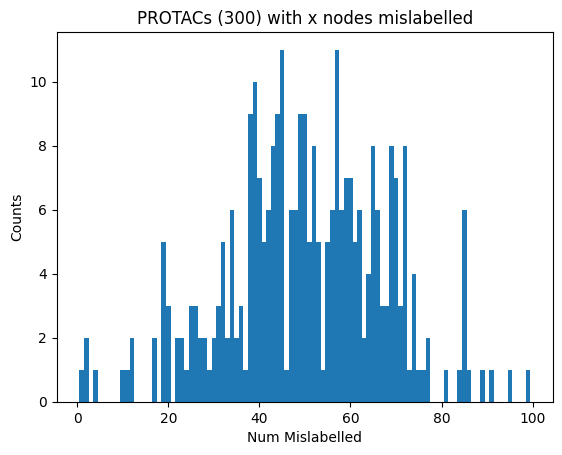

In [13]:
#Bar plot for Num nodes mislabelled nodes for whole PROTAC.
plt.bar(num_mislabelled.keys(), num_mislabelled.values(), 1)

plt.title(f'PROTACs ({len(chosen_dataset)}) with x nodes mislabelled')
plt.xlabel('Num Mislabelled')
plt.ylabel('Counts')
plt.show()



Num PROTACs in set: 300


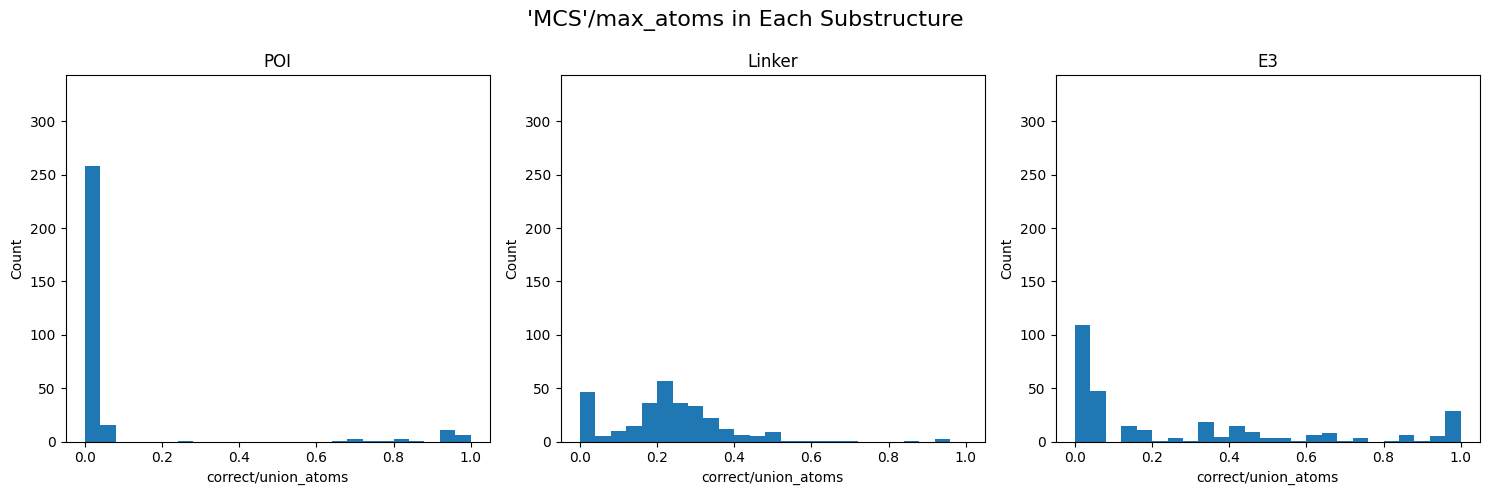

In [14]:
print(f'Num PROTACs in set: {len(POI_MCS_maxatoms_list)}')

fig_width = 15  # Adjust the width as needed
fig_height = 5  # Adjust the height as needed to make subplots square

fig_hist_MCS, axes_hist_MCS = plt.subplots(1, 3, figsize=(fig_width, fig_height))

# Use fig_hist_MCS for setting the super title
fig_hist_MCS.suptitle("'MCS'/max_atoms in Each Substructure", fontsize=16)

substructure_str = ['POI', 'Linker', 'E3']
max_y_val = 0  # Variable to store the maximum y-value across all histograms

# Calculate the maximum y-value without plotting
for X_MCS_maxatoms_list in [POI_MCS_maxatoms_list, Linker_MCS_maxatoms_list, E3_MCS_maxatoms_list]:
    binwidth = 1/25
    bin_setting = np.arange(min(X_MCS_maxatoms_list), max(X_MCS_maxatoms_list) + binwidth, binwidth)
    counts, _ = np.histogram(X_MCS_maxatoms_list, bins=bin_setting)
    max_y_val = max(max_y_val, max(counts))*1.1

# Now plot and set the same y-axis limits
for class_label, X_MCS_maxatoms_list in enumerate([POI_MCS_maxatoms_list, Linker_MCS_maxatoms_list, E3_MCS_maxatoms_list]):
    binwidth = 1/25
    bin_setting = np.arange(0, 1 + binwidth, binwidth)

    axes_hist_MCS[class_label].hist(x=X_MCS_maxatoms_list, bins=bin_setting)
    axes_hist_MCS[class_label].set_ylim(0, max_y_val)  # Set the same y-axis limits
    axes_hist_MCS[class_label].set_xlabel('correct/union_atoms')
    axes_hist_MCS[class_label].set_ylabel('Count')
    axes_hist_MCS[class_label].set_title(f'{substructure_str[class_label]}')

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust the top padding to make room for the super title
plt.show()

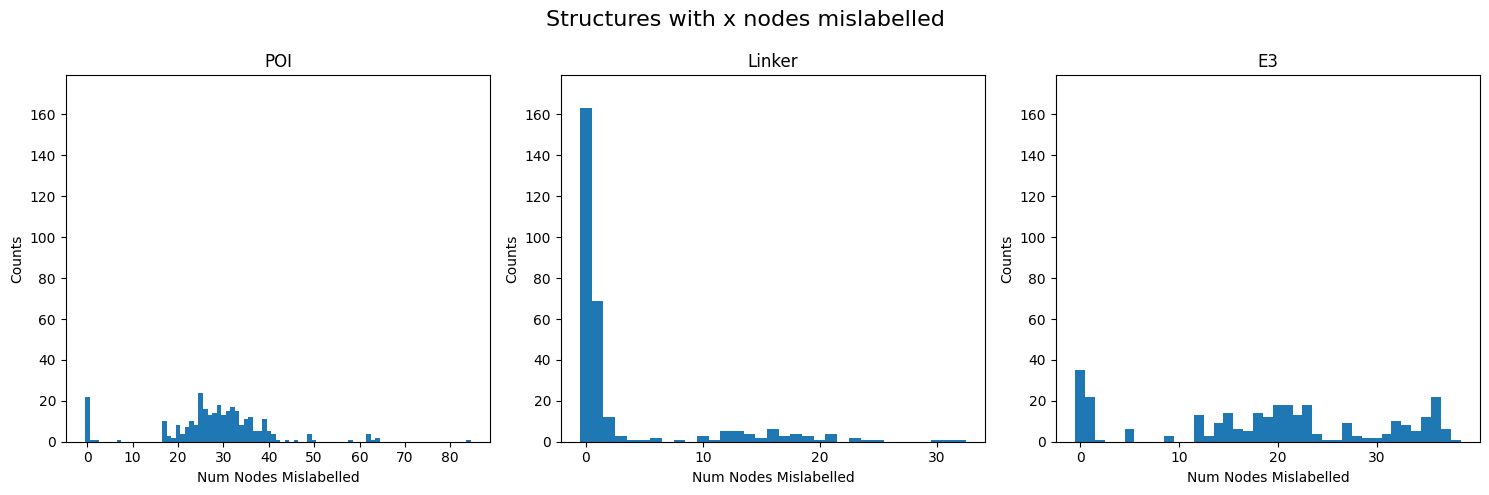

In [15]:
fig_width = 15  # Adjust the width as needed
fig_height = 5  # Adjust the height as needed for the bar plots

fig_bar, axes_bar = plt.subplots(1, 3, figsize=(fig_width, fig_height))
fig_bar.suptitle("Structures with x nodes mislabelled", fontsize=16)
substructure_str = ['POI', 'Linker', 'E3']

# Assuming you have separate num_mislabelled dictionaries for each substructure
num_mislabelled_dicts = [num_mislabelled_POI, num_mislabelled_Linker, num_mislabelled_E3]

# Find the maximum y-value (count) across all substructures
max_y_val = 0
for num_mislabelled_struct in num_mislabelled_dicts:
    max_y_val = max(max_y_val, max(num_mislabelled_struct.values(), default=0))
max_y_val=max_y_val*1.1

for class_label, num_mislabelled_struct in enumerate(num_mislabelled_dicts):
    axes_bar[class_label].bar(num_mislabelled_struct.keys(), num_mislabelled_struct.values(), 1)
    axes_bar[class_label].set_title(f'{substructure_str[class_label]}')
    axes_bar[class_label].set_xlabel('Num Nodes Mislabelled')
    axes_bar[class_label].set_ylabel('Counts')
    
    # Set the same y-axis limits
    axes_bar[class_label].set_ylim(0, max_y_val)

    # Set the x-axis ticks based on the current subplot's data
    max_mislabeled = max(num_mislabelled_struct.keys(), default=0)
    step_size = 5 if max_mislabeled <= 30 else 10
    axes_bar[class_label].set_xticks(range(0, max_mislabeled + 1, step_size))

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust for the super title
plt.show()




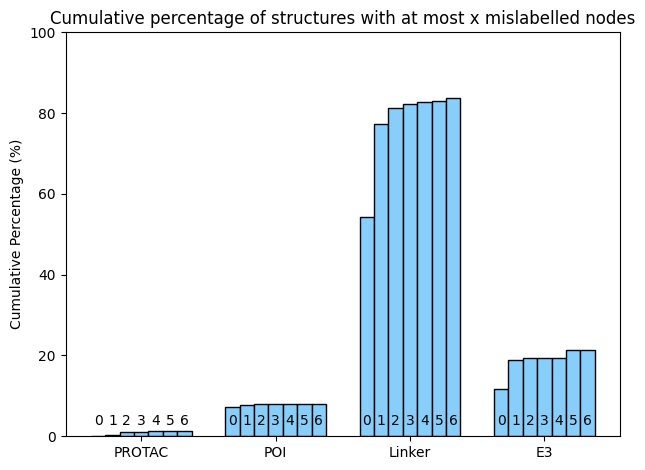

In [16]:

num_mislabelled_table_limit = 6
substructure_str = ['PROTAC', 'POI', 'Linker', 'E3']
cumulative_percentages = {sub: [0] * (num_mislabelled_table_limit + 1) for sub in substructure_str}

num_mislabelled_dicts = [num_mislabelled, num_mislabelled_POI, num_mislabelled_Linker, num_mislabelled_E3]


# Variable for adjusting the height of the numbers
number_y_position = 2  # Adjust this value to change the vertical position of the numbers

# Data preparation
for sub_index, num_mislabelled_struct in enumerate(num_mislabelled_dicts):
    cumulative_prop = 0
    for i in range(num_mislabelled_table_limit + 1):
        if i in num_mislabelled_struct:
            current_prop = num_mislabelled_struct[i] / len(chosen_dataset)
        else:
            current_prop = 0
        cumulative_prop += current_prop
        cumulative_percentages[substructure_str[sub_index]][i] = cumulative_prop * 100

# Plotting
fig, ax = plt.subplots()
bar_width = 0.15  # Width of each bar
spacing = 0.05  # Spacing between groups
default_color = 'lightskyblue'  # Light blue color for the bars

for i in range(num_mislabelled_table_limit + 1):
    for sub_index, sub in enumerate(substructure_str):
        # Calculate the x position for each bar within the group
        x_pos = sub_index * (num_mislabelled_table_limit + 1) * (bar_width + spacing) + i * bar_width
        ax.bar(x_pos, cumulative_percentages[sub][i], bar_width, color=default_color, edgecolor='black')

# Adding numbering below each bar
for sub_index, sub in enumerate(substructure_str):
    for i in range(num_mislabelled_table_limit + 1):
        x_pos = sub_index * (num_mislabelled_table_limit + 1) * (bar_width + spacing) + i * bar_width
        ax.text(x_pos, number_y_position, str(i), ha='center', va='bottom')

# Labels and Ticks
ax.set_ylabel('Cumulative Percentage (%)')
ax.set_title('Cumulative percentage of structures with at most x mislabelled nodes')
ax.set_xticks([(num_mislabelled_table_limit + 1) * (bar_width + spacing) * sub_index + (num_mislabelled_table_limit / 2) * bar_width for sub_index in range(len(substructure_str))])
ax.set_xticklabels(substructure_str)
ax.set_ylim([0, 100])  # Adjust y-axis to fit the text

plt.tight_layout()
plt.show()



Linker for protac idx 5 predicted to have no size. Define as invalid
Linker for protac idx 29 predicted to have no size. Define as invalid
Linker for protac idx 87 predicted to have no size. Define as invalid
Linker for protac idx 115 predicted to have no size. Define as invalid
Linker for protac idx 158 predicted to have no size. Define as invalid
Linker for protac idx 164 predicted to have no size. Define as invalid
Linker for protac idx 208 predicted to have no size. Define as invalid
Linker for protac idx 210 predicted to have no size. Define as invalid
Linker for protac idx 252 predicted to have no size. Define as invalid
Linker for protac idx 275 predicted to have no size. Define as invalid
['POI', 'Linker', 'E3'] :
invalid_smiles_counter_substructures: [0, 10, 0]
valid_smiles_counter_substructures: [300, 290, 300]
valid_protac_substructure_split_counter: 290
chosen_dataset PROTACDataset(300)
invalid_smiles_percentage_substructures: [0.0, 3.3, 0.0]
valid_smiles_percentage_substru

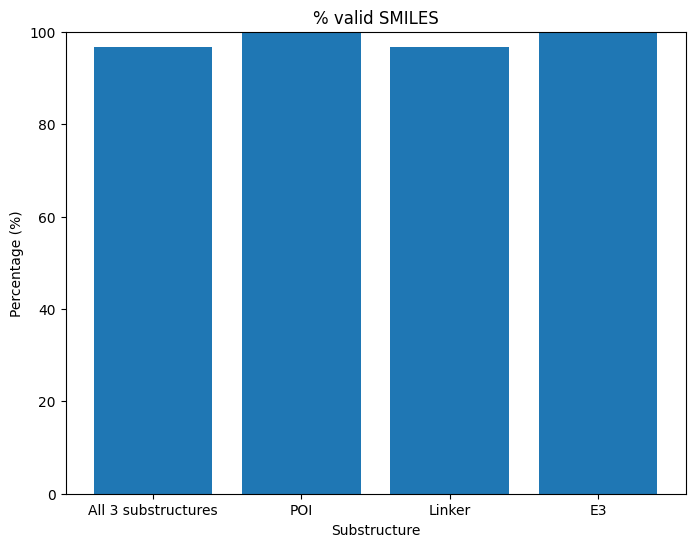

In [17]:
# number of valid smiles
# Convert G -> mol -> SMILES

#TODO I should store pos from the generated graph, likewise, I should store atom identity for simple downstream processing.



invalid_smiles_counter_substructures = [0, 0, 0]
valid_smiles_counter_substructures = [0, 0, 0]
valid_protac_substructure_split_counter = [0, 0]  #first element is the counter, second element is a temporary variable which counts 0, 1, 2, for each substructure, and when it becomes 2 it adds 1 to the first elements and resets itself.

for idx in range(len(chosen_dataset)):#[204, 317, 318]: #range(len(chosen_dataset)):
    #idx=5
    substructure_smiles = chosen_dataset[idx].substructure_smiles
    protac_smile = chosen_dataset[idx].smiles
    graph = chosen_dataset[idx].G
    #vizualize_protac_From_Smile(protac_smile, node_size=80)


        
    chosen_datapoint=chosen_dataset[idx]
    protac_smile = chosen_datapoint.smiles
    substructure_smiles = chosen_datapoint.substructure_smiles
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    protac_mol = Chem.MolFromSmiles(protac_smile)
    G_pred=chosen_datapoint.G

    pt = GetPeriodicTable()
    atom_types = ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I']  # Common atom types, add more as needed

    # Create a data object
    molecule_data = Data(x=chosen_datapoint.x, edge_index=chosen_datapoint.edge_index, edge_attr=chosen_datapoint.edge_attr, G=G_pred)

    # Make predictions
    class_predictions, probabilities = predict(model, molecule_data)
    class_predictions_list = class_predictions.tolist()
    color_mapping = {0: 'red', 1: 'gray', 2: 'blue'}     # Define color mapping
    colours_pred = [color_mapping[class_pred] for class_pred in class_predictions_list]     # Map each class prediction to its corresponding color

    # Create a figure and axes for the predicted graph
    G_pred, pos = assign_pos_to_graph(smile=protac_smile, G=G_pred)
    fig_pred, ax_pred = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_pred, pos, node_color=colours_pred, with_labels=False, node_size=100, ax=ax_pred)
    ax_pred.set_title("Predicted")
    ax_pred.axis('equal')
    ax_pred.axis('off')  # Optional: to turn off the axis
    plt.close(fig_pred)  # Close the figure to prevent it from being displayed

    # Create a figure and axes for the ground truth graph
    G_gt, colors_groundtruth = make_groundtruth_graph(protac_smile, substructure_smiles)
    
    fig_gt, ax_gt = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_gt, pos, node_color=colors_groundtruth, with_labels=False, node_size=100, ax=ax_gt)
    ax_gt.set_title("Ground Truth")
    ax_gt.axis('equal')
    ax_gt.axis('off')  # Optional: to turn off the axis
    plt.close(fig_gt)  # Close the figure to prevent it from being displayed

    #print('index: ', idx)
    #print('protac_smile', protac_smile)
    # Combine and display the two figures
    #combine_two_figures(fig_gt, fig_pred)


    #class_label = 0
    #node_indices_substructure = [i*(prediction == class_label) for i, prediction in enumerate(class_predictions.tolist()) if prediction == class_label]
    #subgraph_substructure = graph.subgraph(node_indices_substructure)
    #is_graph_connected = nx.is_connected(subgraph_substructure)
    #print("Graph is connected:", is_graph_connected)
    #vizualize_protac_From_Graph(subgraph_substructure, node_size=80)

    #vizualize_protac_From_Graph(graph, node_size=80)

    substruct_str = ['POI', 'Linker', 'E3']
    #print("PROTAC:")
    #vizualize_protac_From_Graph(graph, node_size=80)
    valid_protac_substructure_split_counter[1] = 0
    for class_label in [0, 1, 2]:
        node_indices_substructure = [i*(prediction == class_label) for i, prediction in enumerate(class_predictions.tolist()) if prediction == class_label]
        subgraph_substructure = graph.subgraph(node_indices_substructure)
        # Create a mapping from old indices (from the original graph) to new indices (for the RDKit molecule)
        index_mapping = {old_index: new_index for new_index, old_index in enumerate(subgraph_substructure.nodes())}
        if len(subgraph_substructure) > 0:
            is_graph_connected = nx.is_connected(subgraph_substructure)
        else:
            is_graph_connected = None
        #print(f'Predicted {substruct_str[class_label]} is connected: {is_graph_connected}')
        #vizualize_protac_From_Graph(subgraph_substructure, node_size=80)
        #print(f'subgraph_substructure, {subgraph_substructure}' )
        #print(f'graph: {graph}')

        #print("Graph is connected:", is_graph_connected)
        try: 
            pass
            #mol_substructure = graph_to_mol(subgraph_substructure)
            #reassembled_protac_smile = Chem.MolToSmiles(mol_substructure)
        except RuntimeError:
            pass
            #print("invalid smile")
        if is_graph_connected is True:
            new_mol = Chem.RWMol()

            # Add atoms to the molecule
            for node, attr in subgraph_substructure.nodes(data=True):
                atom = Chem.Atom(attr['atomic_num'])
                
                new_mol.AddAtom(atom)

            # Add bonds to the molecule
            for start, end, attr in subgraph_substructure.edges(data=True):
                # Map the original node indices to the new indices
                new_start = index_mapping[start]
                new_end = index_mapping[end]

                bond_type = attr['bond_type']
                new_mol.AddBond(new_start, new_end, bond_type)

            adjust_bond_types(new_mol)
            adjust_bond_types_for_kekulization(new_mol)

            # Convert to a standard RDKit molecule and return
            mol_substructure = new_mol.GetMol()
            reassembled_substructure_smile = Chem.MolToSmiles(mol_substructure)
            #print(f'reassembled_substructure_smile ({substruct_str[class_label]}): {reassembled_substructure_smile}')


            
            if reassembled_substructure_smile is None:
                invalid_smiles_counter_substructures[class_label] += 1
                print("is none")
            elif isinstance(reassembled_substructure_smile, str): 
                valid_smiles_counter_substructures[class_label] += 1
                valid_protac_substructure_split_counter[1] += 1
            else:
                print("is else")
                print(type(reassembled_substructure_smile))
                print(reassembled_substructure_smile)
                print(invalid_smiles_counter_substructures)
        elif is_graph_connected is None:
            invalid_smiles_counter_substructures[class_label] += 1          #If a subgraph has no length (including linkers) => Define as incorrect
            print(f'{substruct_str[class_label]} for protac idx {idx} predicted to have no size. Define as invalid')
        else:
            invalid_smiles_counter_substructures[class_label] += 1
            print(f'invalid smiles for protac idx: {idx}, {substruct_str[class_label]}')

        #print(f'Pre: {valid_protac_substructure_split_counter}')
        if valid_protac_substructure_split_counter[1] == 3:
            valid_protac_substructure_split_counter[0] += 1
            valid_protac_substructure_split_counter[1] = 0
        #print(f'post: {valid_protac_substructure_split_counter}')


                
            
            #"""try:
            #    Chem.Kekulize(mol, clearAromaticFlags=True)
            #    Chem.SanitizeMol(mol)
            #except Chem.KekulizeException:
             #   print("Kekulization issue: Can't kekulize mol.")
            #except Chem.AtomKekulizeException:
             #   print("Sanitization issue: non-ring atom marked aromatic")"""


            #reassembled_protac_smile = Chem.MolToSmiles(mol)
    #print("--------------------------------------------------------------------------------------------------------------------------------")
    

print(substruct_str, ":")
print(f'invalid_smiles_counter_substructures: {invalid_smiles_counter_substructures}')
print(f'valid_smiles_counter_substructures: {valid_smiles_counter_substructures}')
print(f'valid_protac_substructure_split_counter: {valid_protac_substructure_split_counter[0]}')
print(f'chosen_dataset {chosen_dataset}')
invalid_smiles_percentage_substructures = [round(100*substruct_count/ len(chosen_dataset),1) for substruct_count in invalid_smiles_counter_substructures]
valid_smiles_percentage_substructures = [round(100*substruct_count/ len(chosen_dataset),1) for substruct_count in valid_smiles_counter_substructures]
valid_protac_substructure_split_percentage = round(100*valid_protac_substructure_split_counter[0]/ len(chosen_dataset),1)
print(f'invalid_smiles_percentage_substructures: {invalid_smiles_percentage_substructures}')
print(f'valid_smiles_percentage_substructures: {valid_smiles_percentage_substructures}')
print(f'valid_protac_substructure_split_percentage: {valid_protac_substructure_split_percentage}')



# Percentages for each category
percentages = [valid_protac_substructure_split_percentage, valid_smiles_percentage_substructures[0], valid_smiles_percentage_substructures[1], valid_smiles_percentage_substructures[2]]  # Replace with actual percentages

# Corresponding names for the x-ticks
names = ['All 3 substructures', 'POI', 'Linker', 'E3']

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(names, percentages)

# Set the title and labels
plt.title('% valid SMILES')
plt.xlabel('Substructure')
plt.ylabel('Percentage (%)')

# Set the range of the y-axis
plt.ylim(0, 100)

# Display the plot
plt.show()

Accuracy of 0.3489967637540453 for chosen dataset


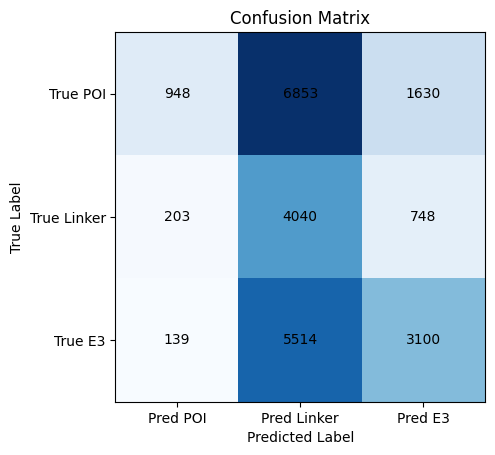

Sum of rows are sum of the number of nodes in the true substructure. 
Example: 7 True L & Pred Linker, means that the model correctly predicted 7 linker nodes. 
         3 True Linker & Pred E3, means that 3 nodes that are actually a part of the linker were predicted as E3 nodes


In [18]:

# Convert the matrix to a NumPy array for better handling
confusion_matrix_np = np.array(Confusion3Matrix_sum) 

# Create the heatmap
plt.imshow(confusion_matrix_np, cmap='Blues', interpolation='nearest')

# Add color bar
#plt.colorbar()

# Annotate the heatmap with text
for i in range(confusion_matrix_np.shape[0]):
    for j in range(confusion_matrix_np.shape[1]):
        text = plt.text(j, i, confusion_matrix_np[i, j], ha="center", va="center", color="black")

Correct_predictions = sum(np.diag(confusion_matrix_np))
total_predictions = np.sum(confusion_matrix_np)
chosen_dataset_accuracy = Correct_predictions/total_predictions
#print(f'Confusion matrix reproduces validation accuracy: {val_accuracy == test_accuracy}')
print(f'Accuracy of {chosen_dataset_accuracy} for chosen dataset')


# Adding labels for clarity
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Add x and y ticks (optional, for better clarity)
plt.xticks(range(len(confusion_matrix_np)), ['Pred POI', 'Pred Linker', 'Pred E3'])
plt.yticks(range(len(confusion_matrix_np)), ['True POI', 'True Linker', 'True E3'])

plt.show()
print("Sum of rows are sum of the number of nodes in the true substructure. \nExample: 7 True L & Pred Linker, means that the model correctly predicted 7 linker nodes. \n         3 True Linker & Pred E3, means that 3 nodes that are actually a part of the linker were predicted as E3 nodes")

In [19]:
# Get size distribution of each substructure

from collections import Counter


poi_size_count = {}
linker_size_count = {}
e3_size_count = {}

for idx in range(len(chosen_dataset)):
    true_class_labels = chosen_dataset[idx].node_substructure_label.argmax(dim=1)
    counts = Counter(true_class_labels.tolist())
    #print(counts)
    if counts[0] not in poi_size_count:
        poi_size_count[counts[0]] = 1
    else:
        poi_size_count[counts[0]] += 1
    if counts[1] not in linker_size_count:
        linker_size_count[counts[1]] = 1
    else:
        linker_size_count[counts[1]] += 1
    if counts[2] not in e3_size_count:
        e3_size_count[counts[2]] = 1
    else:
        e3_size_count[counts[2]] += 1

#print(poi_size_count)
#print(linker_size_count)
#print(e3_size_count)

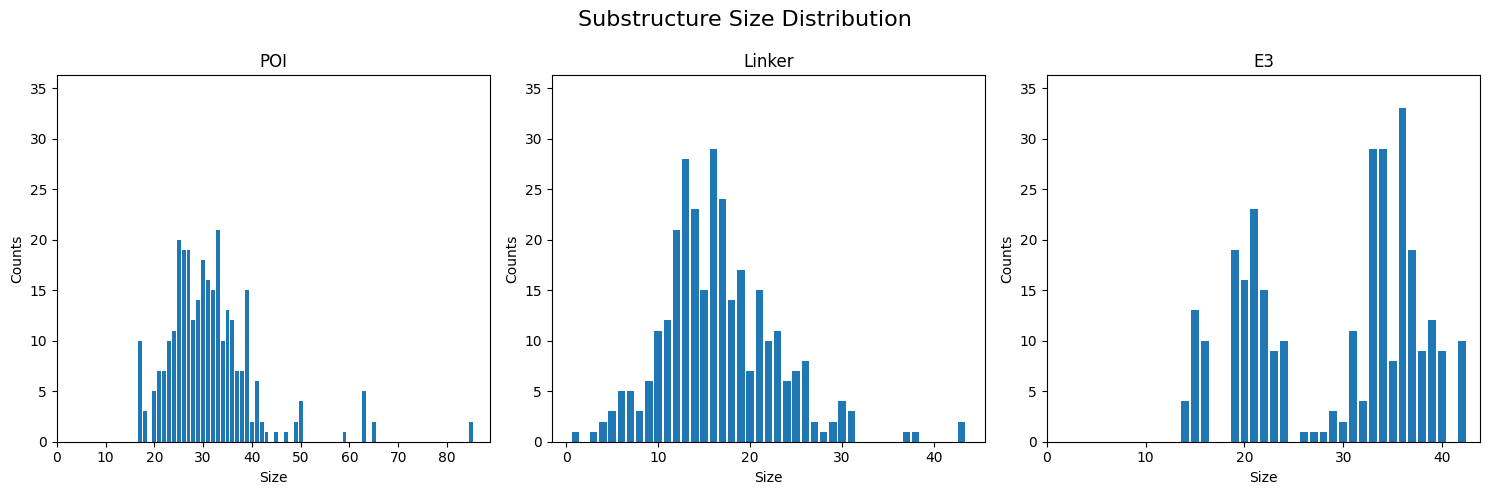

In [20]:

fig_width = 15  # Adjust the width as needed
fig_height = 5  # Adjust the height as needed for the bar plots

# Create subplots
fig_bar, axes_bar = plt.subplots(1, 3, figsize=(fig_width, fig_height))
fig_bar.suptitle("Substructure Size Distribution", fontsize=16)
substructure_str = ['POI', 'Linker', 'E3']

# Assuming you have separate size count dictionaries for each substructure
size_count_dicts = [poi_size_count, linker_size_count, e3_size_count]

# Find the maximum y-value (count) across all substructures
max_y_val = 0
for size_count_struct in size_count_dicts:
    max_y_val = max(max_y_val, max(size_count_struct.values(), default=0))
max_y_val = max_y_val * 1.1  # Add 10% headroom for the y-axis

# Plot each substructure size count in a separate subplot
for class_label, size_count_struct in enumerate(size_count_dicts):
    keys = list(size_count_struct.keys())
    values = list(size_count_struct.values())
    axes_bar[class_label].bar(keys, values)
    axes_bar[class_label].set_title(substructure_str[class_label])
    axes_bar[class_label].set_xlabel('Size')
    axes_bar[class_label].set_ylabel('Counts')
    
    # Set the same y-axis limits
    axes_bar[class_label].set_ylim(0, max_y_val)

    # Set the x-axis ticks based on the current subplot's data
    if keys:  # Make sure there are keys to plot
        max_size = max(keys)
        step_size = 5 if max_size <= 30 else 10
        axes_bar[class_label].set_xticks(range(0, max_size + 1, step_size))

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust for the super title
plt.show()

# Playground

In [21]:
chosen_dataset

PROTACDataset(300)

COc1cc(OC)c(C=CS(=O)(=O)Cc2ccc(OC)c(NCCC(=O)NCCOC(=O)C(CC(C)C)NC(=O)C(O)C(N)Cc3ccccc3)c2)c(OC)c1
PROTAC 1


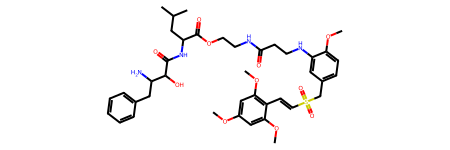

MurckoScaffold


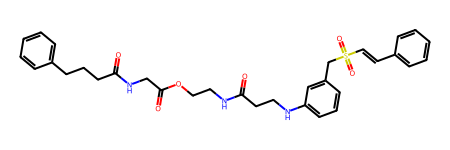

In [22]:
idx_list = [1]
for idx in idx_list:
    protac_smile = chosen_dataset[idx].smiles
    print(protac_smile)
    mol = Chem.MolFromSmiles(protac_smile)
    mol_MurckoScaffold_raw = Chem.Scaffolds.MurckoScaffold.GetScaffoldForMol(mol)
    protac_smile_MurckoScaffold = Chem.MolToSmiles(mol_MurckoScaffold_raw)
    mol_MurckoScaffold = Chem.MolFromSmiles(protac_smile_MurckoScaffold)
    G_MurckoScaffold = mol_to_graph(mol=mol_MurckoScaffold,graph_descriptor_list=[])
    assign_pos_to_graph(smile=protac_smile_MurckoScaffold, G = G_MurckoScaffold)
    G = mol_to_graph(mol=mol,graph_descriptor_list=[])
    assign_pos_to_graph(smile=protac_smile, G = G)


    #Vizualization
    print("PROTAC", idx,)
    #vizualize_protac_From_Graph(G, node_size=80)
    display(mol)

    print("MurckoScaffold")
    #vizualize_protac_From_Graph(G_MurckoScaffold, node_size=80)
    display(mol_MurckoScaffold)